# Chunk-shape sensitivity

Fixed `N = 500_000` point cloud uniformly distributed in `[0, 1000)³`.
Sweep `chunk_shape` ∈ `{50, 100, 200, 400, 800}` (uniform 3-tuples) and
measure write time, full read, **single-vertex read** (one chunk via the
lazy API), disk size, and chunk count.  `bin_shape = chunk_shape / 4`
for every run.

The single-vertex read is the headline.  Small chunks pay per-file
metadata overhead per access; large chunks return a lot more data than
the single vertex needed.  Expect a U-shape.

In [10]:
import os, time, tempfile, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _time(fn, *args, **kwargs):
    """Call fn(*args, **kwargs); return (elapsed_seconds, result)."""
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return time.perf_counter() - t0, out


def _store_bytes(path):
    """Total on-disk size of a store directory, in bytes."""
    p = Path(path)
    return sum(f.stat().st_size for f in p.rglob('*') if f.is_file())


def _new_store(prefix):
    """Fresh tempdir + zarrvectors path."""
    return Path(tempfile.mkdtemp(prefix=f'zvbench_{prefix}_')) / 'store.zarrvectors'


N_RUNS = 10
T95_DF9 = 2.262  # scipy.stats.t.ppf(0.975, df=9) — hard-coded to avoid scipy dep


def _mean_ci95(samples):
    """(mean, half-width) for a 1-D sample using Student's t, df=n-1."""
    arr = np.asarray(samples, dtype=float)
    if arr.size < 2:
        return float(arr.mean()) if arr.size else 0.0, 0.0
    m = arr.mean()
    s = arr.std(ddof=1)
    hw = T95_DF9 * s / np.sqrt(arr.size)
    return float(m), float(hw)

## 1 · Setup

In [ ]:
from zarr_vectors.types.points import write_points, read_points
from zarr_vectors.lazy import open_zv

N           = 10_000_000
CHUNK_SIZES = [100, 200, 400, 800]
DOMAIN      = 1000.0
SEED        = 0

## 2 · Run the sweep

In [12]:
rng = np.random.default_rng(SEED)
positions = rng.uniform(0, DOMAIN, (N, 3)).astype(np.float32)

metrics = ['write_s', 'read_all_s', 'read_one_s']
raw = {m: np.zeros((len(CHUNK_SIZES), N_RUNS)) for m in metrics}
sizes_MB    = np.zeros(len(CHUNK_SIZES))
chunk_count = np.zeros(len(CHUNK_SIZES))

for i, cs in enumerate(CHUNK_SIZES):
    chunk_shape = (float(cs),) * 3
    bin_shape   = (cs / 4.0,) * 3

    for run in range(N_RUNS):
        store = _new_store(f'cs_{cs}_run{run}')

        t_w, _ = _time(
            write_points, store, positions,
            chunk_shape=chunk_shape, bin_shape=bin_shape,
        )
        t_r, _ = _time(read_points, store)

        # Single-vertex (= one chunk via lazy API) read, like
        # benchmarks/01_size_scaling.ipynb.  Open + chunk listing +
        # one chunk decode.
        def _read_one():
            zv = open_zv(store)
            keys = zv[0].vertices._chunk_keys  # noqa: SLF001
            return zv[0].vertices[keys[0]].compute() if keys else None
        t_o, _ = _time(_read_one)

        raw['write_s'][i, run]    = t_w
        raw['read_all_s'][i, run] = t_r
        raw['read_one_s'][i, run] = t_o

        if run == 0:
            sizes_MB[i]    = _store_bytes(store) / 1e6
            chunk_count[i] = len(open_zv(store)[0].chunk_keys)

        shutil.rmtree(Path(store).parent, ignore_errors=True)

rows = []
for i, cs in enumerate(CHUNK_SIZES):
    row = {'chunk_shape': cs, 'size_MB': round(sizes_MB[i], 2),
           'chunk_count': int(chunk_count[i])}
    for m in metrics:
        mean, hw = _mean_ci95(raw[m][i])
        row[f'{m}_mean'] = round(mean, 4)
        row[f'{m}_hw']   = round(hw,   4)
    rows.append(row)
df = pd.DataFrame(rows)

## 3 · Results

In [13]:
df

,chunk_shape,size_MB,chunk_count,write_s_mean,write_s_hw,read_all_s_mean,read_all_s_hw,read_one_s_mean,read_one_s_hw
0,100,7.66,1000,2.2764,0.1830,3.1037,0.3245,0.4637,0.0346
1,200,6.21,125,0.5664,0.0253,0.4161,0.0443,0.0732,0.0065
2,400,6.05,27,0.3845,0.0122,0.1153,0.0342,0.0263,0.0044
3,800,6.02,8,0.3345,0.0179,0.0518,0.0115,0.0196,0.0019


## 4 · Plot

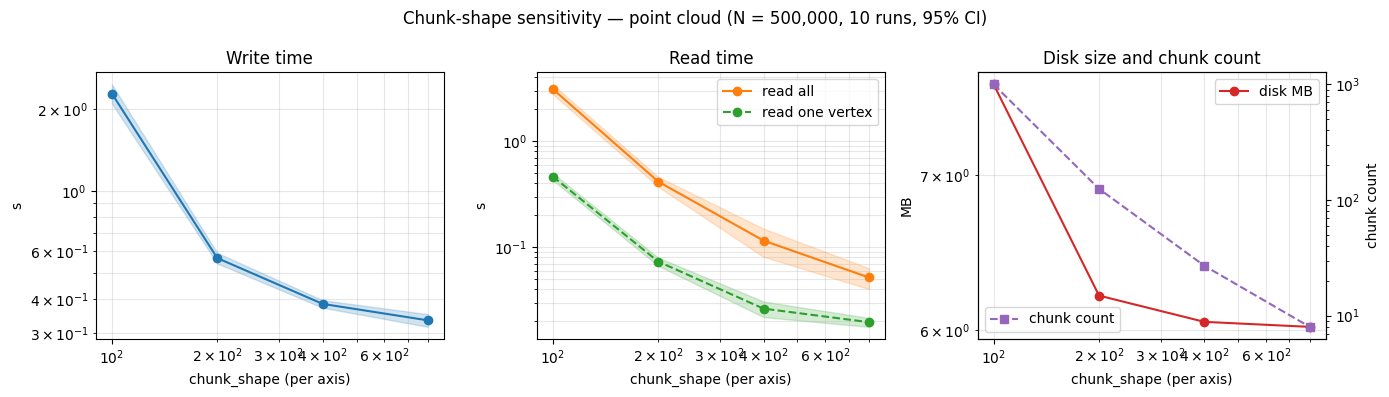

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def _ci_line(ax, key, color, label=None, linestyle='-'):
    mean = df[f'{key}_mean'].values
    hw   = df[f'{key}_hw'].values
    ax.fill_between(df['chunk_shape'], mean - hw, mean + hw,
                    color=color, alpha=0.2)
    ax.loglog(df['chunk_shape'], mean, marker='o', color=color,
              linestyle=linestyle, label=label)

# Panel 1 — write time.
ax = axes[0]
_ci_line(ax, 'write_s', 'C0')
ax.set_xlabel('chunk_shape (per axis)')
ax.set_ylabel('s')
ax.set_title('Write time')
ax.grid(True, which='both', alpha=0.3)

# Panel 2 — read all (solid) + read one vertex (dashed) on the same axes.
ax = axes[1]
_ci_line(ax, 'read_all_s', 'C1', label='read all',     linestyle='-')
_ci_line(ax, 'read_one_s', 'C2', label='read one vertex', linestyle='--')
ax.set_xlabel('chunk_shape (per axis)')
ax.set_ylabel('s')
ax.set_title('Read time')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')

# Panel 3 — disk MB + chunk count on twin axes.
ax = axes[2]
ax.loglog(df['chunk_shape'], df['size_MB'], 'o-', color='C3',
          label='disk MB')
ax.set_xlabel('chunk_shape (per axis)')
ax.set_ylabel('MB')
ax.grid(True, which='both', alpha=0.3)
ax_r = ax.twinx()
ax_r.loglog(df['chunk_shape'], df['chunk_count'], 's--', color='C4',
            label='chunk count')
ax_r.set_ylabel('chunk count')
ax.set_title('Disk size and chunk count')
ax.legend(loc='upper right')
ax_r.legend(loc='lower left')

fig.suptitle(
    f'Chunk-shape sensitivity — point cloud (N = {N:,}, '
    f'{N_RUNS} runs, 95% CI)',
)
plt.tight_layout()